# **STATISTICAL ANALYSIS & INFERENCES**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv


In [ ]:
df = pd.read_csv('movies.csv')
df.head()

,imdb_id,original_title,vote_average,vote_count,revenue_usd,budget_usd,runtime_minutes,original_language,popularity,genres,production_companies,top_casts,director,release_year,release_month,roi_percentage,success_category
0,tt1375666,Inception,8.364,34495,825532764,160000000,148,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",Christopher Nolan,2010,7,416,All-Time Blockbuster
1,tt0816692,Interstellar,8.417,32571,701729206,165000000,169,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","Matthew McConaughey, Anne Hathaway, Jessica Ch...",Christopher Nolan,2014,11,325,Blockbuster
2,tt0468569,The Dark Knight,8.512,30619,1004558444,185000000,152,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","Christian Bale, Heath Ledger, Aaron Eckhart",Christopher Nolan,2008,7,443,All-Time Blockbuster
3,tt0499549,Avatar,7.573,29815,2923706026,237000000,162,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","Sam Worthington, Zoe Saldana, Sigourney Weaver",James Cameron,2009,12,1134,All-Time Blockbuster
4,tt0848228,The Avengers,7.710,29166,1518815515,220000000,143,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,"Downey Jr., Chris Evans, Scarlett Johansson",Joss Whedon Robert,2012,4,590,All-Time Blockbuster


In [ ]:
df.columns

Index(['imdb_id', 'original_title', 'vote_average', 'vote_count',
       'revenue_usd', 'runtime_minutes', 'budget_usd', 'original_language',
       'popularity', 'genres', 'production_companies', 'top_casts', 'director',
       'release_year', 'release_month', 'roi_percentage', 'success_category'],
      dtype='object')

---

# **Statistical Analysis**

---

This section performs a focused statistical analysis of the `movies.csv` dataset. The objectives include:

- Generating descriptive statistics for **budget** and **revenue** to understand central tendency and dispersion.  
- Running **ANOVA** to compare `vote_average` between selected genres (e.g., Drama vs. Action).  
- Applying an **independent samples t-test** to examine rating differences between **High-Budget** (>$100M) and **Low-Budget** movies.  
- Conducting a **Chi-Square test of independence** between **release season** and `success_category`.  
- Computing and visualizing a **correlation matrix** for key numerical features:  
  `budget_usd`, `revenue_usd`, `vote_average`, `vote_count`, `popularity`, `runtime_minutes`.  
- Summarizing insights to provide a clear statistical understanding of the dataset.

---

In [ ]:
df[['budget_usd', 'revenue_usd']].describe()

,budget_usd,revenue_usd
count,1.514000e+03,1.514000e+03
mean,7.091034e+07,2.803320e+08
std,6.470074e+07,3.026904e+08
min,6.000000e+04,0.000000e+00
25%,2.000000e+07,8.858663e+07
50%,5.000000e+07,1.865836e+08
75%,1.030000e+08,3.627176e+08
max,4.600000e+08,2.923706e+09


---

# **ANOVA**

---


## **ANOVA: Comparing Ratings Across Genres**

### **Objective**
Extract two genre groups—**Drama** and **Action**—from the `genres` column and perform a **one-way ANOVA** to compare their mean `vote_average`. The goal is to determine whether the difference in average ratings between these genres is statistically significant.

### **Key Question**
Do **Drama** movies receive higher average ratings than **Action** movies based on ANOVA results?

In [ ]:
drama_ratings = df[df['genres'].str.contains('Drama')]['vote_average']
action_ratings = df[df['genres'].str.contains('Action')]['vote_average']

print("Created drama_ratings and action_ratings Series.")

Created drama_ratings and action_ratings Series.


In [ ]:
from scipy.stats import f_oneway

# Perform ANOVA test
f_statistic, p_value = f_oneway(drama_ratings, action_ratings)

# Print ANOVA results
print(f"ANOVA F-statistic: {f_statistic:.3f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Calculate and print mean vote averages
mean_drama_rating = drama_ratings.mean()
mean_action_rating = action_ratings.mean()

print(f"\nMean vote_average for Drama movies: {mean_drama_rating:.3f}")
print(f"Mean vote_average for Action movies: {mean_action_rating:.3f}")

ANOVA F-statistic: 202.753
ANOVA P-value: 0.000

Mean vote_average for Drama movies: 7.362
Mean vote_average for Action movies: 6.788


## **Analyze IMDb Ratings Across Multiple Genres**

### **Objective**
Perform a **one-way ANOVA** to evaluate whether mean IMDb ratings (`vote_average`) differ significantly across multiple movie genres. This involves extracting distinct genres from the `genres` column and comparing rating distributions across those groups.

### **Key Question**
Are certain genres rated significantly higher or lower than others based on ANOVA results?

In [ ]:
# Split the 'genres' column and flatten the list of lists to get all individual genres
all_genres = df['genres'].str.split(', ').explode()

# Get unique genres
unique_genres = all_genres.unique()

print(f"Number of unique genres: {len(unique_genres)}")
print("Unique genres:\n", unique_genres)

Number of unique genres: 18
Unique genres:
 ['Action' 'Science Fiction' 'Adventure' 'Drama' 'Crime' 'Thriller'
 'Fantasy' 'Comedy' 'Romance' 'Western' 'Mystery' 'War' 'Animation'
 'Family' 'Horror' 'Music' 'History' 'TV Movie']


In [ ]:
genre_ratings = {}
for genre in unique_genres:
    ratings = df[df['genres'].str.contains(genre)]['vote_average']
    if len(ratings) >= 2: # ANOVA requires at least two data points per group
        genre_ratings[genre] = ratings

print(f"Collected vote_averages for {len(genre_ratings)} genres with at least two movies.")
# print("Sample of genre_ratings:")
# for genre, ratings in list(genre_ratings.items())[:3]:
#     print(f"  {genre}: {ratings.head().tolist()}...")

Collected vote_averages for 17 genres with at least two movies.


In [ ]:
from scipy.stats import f_oneway

# Perform ANOVA test
f_statistic, p_value = f_oneway(*genre_ratings.values())

# Print ANOVA results
print(f"ANOVA F-statistic: {f_statistic:.3f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Calculate and print mean vote averages for each genre
print("\nMean vote_average for each genre:")
for genre, ratings in genre_ratings.items():
    print(f"  {genre}: {ratings.mean():.3f}")

ANOVA F-statistic: 23.058
ANOVA P-value: 0.000

Mean vote_average for each genre:
  Action: 6.788
  Science Fiction: 6.835
  Adventure: 6.892
  Drama: 7.362
  Crime: 7.139
  Thriller: 6.932
  Fantasy: 6.882
  Comedy: 6.897
  Romance: 7.124
  Western: 7.214
  Mystery: 6.960
  War: 7.490
  Animation: 7.186
  Family: 7.034
  Horror: 6.703
  Music: 7.329
  History: 7.411


## **Analyze Budgets Across Genres**

### **Objective**
Perform a **one-way ANOVA** to determine whether production budgets (`budget_usd`) differ significantly across various movie genres. This helps identify whether certain genres typically require higher or lower financial investment.

### **Key Question**
Do specific genres consistently have higher production budgets than others?

In [ ]:
genre_budgets = {}
for genre in unique_genres:
    budgets = df[df['genres'].str.contains(genre)]['budget_usd']
    if len(budgets) >= 2: # ANOVA requires at least two data points per group
        genre_budgets[genre] = budgets

print(f"Collected budget_usd for {len(genre_budgets)} genres with at least two movies.")

Collected budget_usd for 17 genres with at least two movies.


In [ ]:
from scipy.stats import f_oneway

# Perform ANOVA test
f_statistic, p_value = f_oneway(*genre_budgets.values())

# Print ANOVA results
print(f"ANOVA F-statistic: {f_statistic:.3f}")
print(f"ANOVA P-value: {p_value:.3f}")

# Calculate and print mean budget_usd for each genre
print("\nMean budget_usd for each genre:")
for genre, budgets in genre_budgets.items():
    print(f"  {genre}: {budgets.mean():,.0f}")

ANOVA F-statistic: 67.066
ANOVA P-value: 0.000

Mean budget_usd for each genre:
  Action: 105,683,736
  Science Fiction: 105,613,561
  Adventure: 119,881,244
  Drama: 45,104,300
  Crime: 52,790,061
  Thriller: 58,809,625
  Fantasy: 101,790,508
  Comedy: 61,679,648
  Romance: 38,480,081
  Western: 68,911,111
  Mystery: 44,839,193
  War: 59,808,974
  Animation: 94,376,228
  Family: 96,930,143
  Horror: 29,897,758
  Music: 36,161,538
  History: 59,669,543


## **ANOVA Tests Findings Summary**

1. **Drama vs. Action Ratings (Two-Group ANOVA)**  
Drama films have significantly higher IMDb ratings than Action films  
(F = 202.75, p < 0.001).  
Average ratings: Drama = 7.36, Action = 6.79.

2. **Ratings Across Multiple Genres (ANOVA)**  
IMDb ratings differ significantly across genres  
(F = 23.06, p < 0.001).  
War, History, and Drama score higher on average, while Action and Horror rate lower.  
Genre clearly influences audience ratings.

3. **Budgets Across Genres (ANOVA)**  
Production budgets vary widely by genre  
(F = 67.07, p < 0.001).  
Adventure, Action, and Sci-Fi have the highest budgets, while Horror, Music, and Romance operate on much smaller budgets.

---

# **T-Tests**

---


## **Independent Samples T-Tests**

1. **High Budget vs. Low Budget (Ratings)**

2. **High Revenue (> `$300M`) vs. Low Revenue (≤ `$300M`):**  
   Compare differences in mean IMDb ratings (`vote_average`).

3. **Summer vs. Winter Releases:**  
   Test whether `revenue_usd` differs significantly across seasons using the `release_season` column.

4. **Long Runtime vs. Short Runtime:**  
   Compare `vote_average` for movies with runtime **above the median** vs. **at or below the median**.

## **T-Test: Budget vs. IMDb Ratings**

### **Objective**
Divide movies into **High Budget** (budget_usd > `$100M`) and **Low Budget** (budget_usd ≤ `$100M`) groups, then perform an **independent samples t-test** to evaluate whether their mean IMDb ratings (`vote_average`) differ significantly.

### **Key Question**
Do high-budget films receive higher (or lower) average ratings compared to low-budget films based on the t-test results?

In [ ]:
high_budget_ratings = df[df['budget_usd'] > 100000000]['vote_average']
low_budget_ratings = df[df['budget_usd'] <= 100000000]['vote_average']

print(f"Number of high budget movies: {len(high_budget_ratings)}")
print(f"Number of low budget movies: {len(low_budget_ratings)}")

Number of high budget movies: 384
Number of low budget movies: 1130


In [ ]:
from scipy.stats import ttest_ind

# Perform independent samples T-test
t_statistic, p_value = ttest_ind(high_budget_ratings, low_budget_ratings)

# Print T-test results
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Calculate and print mean vote averages
mean_high_budget_rating = high_budget_ratings.mean()
mean_low_budget_rating = low_budget_ratings.mean()

print(f"\nMean vote_average for High Budget movies: {mean_high_budget_rating:.3f}")
print(f"Mean vote_average for Low Budget movies: {mean_low_budget_rating:.3f}")

T-statistic: -6.842
P-value: 0.000

Mean vote_average for High Budget movies: 6.806
Mean vote_average for Low Budget movies: 7.091


## **T-Test: High vs. Low Revenue Movie Ratings**

### **Objective**
Classify movies into **High Revenue** (revenue_usd > `$300M`) and **Low Revenue** (revenue_usd ≤ `$300M`) groups, then perform an **independent samples t-test** to compare their mean IMDb ratings (`vote_average`).

### **Key Question**
Do high-revenue movies receive significantly different audience ratings compared to low-revenue movies?


In [ ]:
high_revenue_ratings = df[df['revenue_usd'] > 300000000]['vote_average']
low_revenue_ratings = df[df['revenue_usd'] <= 300000000]['vote_average']

print(f"Number of high revenue movies: {len(high_revenue_ratings)}")
print(f"Number of low revenue movies: {len(low_revenue_ratings)}")

Number of high revenue movies: 490
Number of low revenue movies: 1024


In [ ]:
from scipy.stats import ttest_ind

# Perform independent samples T-test
t_statistic, p_value = ttest_ind(high_revenue_ratings, low_revenue_ratings)

# Print T-test results
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Calculate and print mean vote averages
mean_high_revenue_rating = high_revenue_ratings.mean()
mean_low_revenue_rating = low_revenue_ratings.mean()

print(f"\nMean vote_average for High Revenue movies: {mean_high_revenue_rating:.3f}")
print(f"Mean vote_average for Low Revenue movies: {mean_low_revenue_rating:.3f}")

T-statistic: 0.656
P-value: 0.512

Mean vote_average for High Revenue movies: 7.036
Mean vote_average for Low Revenue movies: 7.010


## **T-Test: Summer vs. Winter Revenue**

### **Objective**
Use the `release_season` column to compare `revenue_usd` between **Summer** and **Winter** releases through an independent samples t-test.

### **Key Question**
Do movies released in Summer earn significantly more (or less) revenue than those released in Winter?


In [ ]:
def get_release_season(month):
    if month in [6, 7, 8]:
        return 'Summer'
    elif month in [12, 1, 2]:
        return 'Winter'
    else:
        return 'Other'

df['release_season'] = df['release_month'].apply(get_release_season)

summer_revenue = df[df['release_season'] == 'Summer']['revenue_usd']
winter_revenue = df[df['release_season'] == 'Winter']['revenue_usd']

print(f"Number of summer release movies: {len(summer_revenue)}")
print(f"Number of winter release movies: {len(winter_revenue)}")

Number of summer release movies: 432
Number of winter release movies: 331


In [ ]:
from scipy.stats import ttest_ind

# Perform independent samples T-test
t_statistic, p_value = ttest_ind(summer_revenue, winter_revenue)

# Print T-test results
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Calculate and print mean revenues
mean_summer_revenue = summer_revenue.mean()
mean_winter_revenue = winter_revenue.mean()

print(f"\nMean revenue for Summer release movies: {mean_summer_revenue:,.0f}")
print(f"Mean revenue for Winter release movies: {mean_winter_revenue:,.0f}")

T-statistic: 2.037
P-value: 0.042

Mean revenue for Summer release movies: 301,659,947
Mean revenue for Winter release movies: 256,629,519


## **T-Test: Runtime vs. IMDb Rating**

### **Objective**
Split movies into two groups based on the median `runtime_minutes` (Above Median vs. Median or Below). Perform an independent samples t-test to compare their mean IMDb ratings (`vote_average`).

### **Key Question**
Do longer movies receive significantly different ratings compared to shorter movies?

In [ ]:
median_runtime = df['runtime_minutes'].median()

above_median_runtime_ratings = df[df['runtime_minutes'] > median_runtime]['vote_average']
below_median_runtime_ratings = df[df['runtime_minutes'] <= median_runtime]['vote_average']

print(f"Median runtime: {median_runtime} minutes")
print(f"Number of movies with runtime above median: {len(above_median_runtime_ratings)}")
print(f"Number of movies with runtime below/equal to median: {len(below_median_runtime_ratings)}")

Median runtime: 114.5 minutes
Number of movies with runtime above median: 757
Number of movies with runtime below/equal to median: 757


In [ ]:
from scipy.stats import ttest_ind

# Perform independent samples T-test
t_statistic, p_value = ttest_ind(above_median_runtime_ratings, below_median_runtime_ratings)

# Print T-test results
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Calculate and print mean vote averages
mean_above_median_rating = above_median_runtime_ratings.mean()
mean_below_median_rating = below_median_runtime_ratings.mean()

print(f"\nMean vote_average for movies with above median runtime: {mean_above_median_rating:.3f}")
print(f"Mean vote_average for movies with below/equal median runtime: {mean_below_median_rating:.3f}")

T-statistic: 9.577
P-value: 0.000

Mean vote_average for movies with above median runtime: 7.189
Mean vote_average for movies with below/equal median runtime: 6.847


## **T-Test Findings Summary**

### **1. High Budget vs. Low Budget (Ratings)**
Low-budget movies have significantly higher ratings than high-budget films (p < 0.001).  
Greater spending does not translate into better audience reception.

### **2. High Revenue vs. Low Revenue (Ratings)**
No significant rating difference between high- and low-revenue movies (p = 0.512).  
Box-office success does not reflect audience approval.

### **3. Summer vs. Winter Releases (Revenue)**
Summer releases earn significantly more revenue than Winter releases (p = 0.042),  
supporting industry trends of strong Summer box-office performance.

### **4. Runtime vs. Ratings**
Longer movies receive significantly higher ratings than shorter films (p < 0.001),  
suggesting deeper narratives or content richness may influence audience appreciation.

---

### **Overall Insights**
- Higher budgets **do not** guarantee better ratings.  
- Higher revenue **does not** guarantee higher quality.  
- Summer releases tend to earn **more revenue**.  
- Longer films tend to receive **higher ratings**.  

These patterns reveal how production cost, timing, and storytelling length interact with audience perception and financial success.

---

# **CHI SQUARE**

---

## **Chi-Square Test: Release Season vs. Success Category**

### **Objective**
Use the `release_season` column to perform a **Chi-Square test of independence** and evaluate whether movie success (`success_category`) is associated with the season of release.

### **Key Question**
Does the timing of a movie’s release (e.g., Summer, Winter, etc.) have a significant relationship with its success category?

In [ ]:
def get_release_season(month):
    if month in [6, 7, 8]:
        return 'Summer'
    elif month in [12, 1, 2]:
        return 'Winter'
    else:
        return 'Other'

df['release_season'] = df['release_month'].apply(get_release_season)

print("Created 'release_season' column.")
df.head()

Created 'release_season' column.


,imdb_id,original_title,vote_average,vote_count,revenue_usd,runtime_minutes,budget_usd,original_language,popularity,genres,production_companies,top_casts,director,release_year,release_month,roi_percentage,success_category,release_season
0,tt1375666,Inception,8.364,34495,825532764,148,160000000,en,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",Christopher Nolan,2010,7,416,All-Time Blockbuster,Summer
1,tt0816692,Interstellar,8.417,32571,701729206,169,165000000,en,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","Matthew McConaughey, Anne Hathaway, Jessica Ch...",Christopher Nolan,2014,11,325,Blockbuster,Other
2,tt0468569,The Dark Knight,8.512,30619,1004558444,152,185000000,en,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","Christian Bale, Heath Ledger, Aaron Eckhart",Christopher Nolan,2008,7,443,All-Time Blockbuster,Summer
3,tt0499549,Avatar,7.573,29815,2923706026,162,237000000,en,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","Sam Worthington, Zoe Saldana, Sigourney Weaver",James Cameron,2009,12,1134,All-Time Blockbuster,Winter
4,tt0848228,The Avengers,7.710,29166,1518815515,143,220000000,en,98.082,"Science Fiction, Action, Adventure",Marvel Studios,"Downey Jr., Chris Evans, Scarlett Johansson",Joss Whedon Robert,2012,4,590,All-Time Blockbuster,Other


In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(df['release_season'], df['success_category'])

# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Print results
print("Contingency Table:")
print(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3f}")

Contingency Table:
success_category  All-Time Blockbuster  Average / Below Average  Blockbuster  \
release_season                                                                 
Other                              260                       46          206   
Summer                             163                       28          119   
Winter                             118                       20           89   

success_category  Flop / Disaster  Hit / Semi-Hit  Super Hit  
release_season                                                
Other                          42              60        137  
Summer                         19              34         69  
Winter                         20              19         65  

Chi-Square Statistic: 5.158
P-value: 0.880


## **Chi-Square Test: Genre vs. Success Category**

### **Objective**
Expand the `genres` column so each movie–genre pair becomes a separate row, then perform a **Chi-Square test of independence** to examine whether certain genres are associated with specific success categories (e.g., Hit, Flop).

### **Key Question**
Are some genres more likely to produce successful movies than others?


In [ ]:
df_exploded_genres = df.assign(genres=df['genres'].str.split(', ')).explode('genres')

print("Created df_exploded_genres with individual genres and their success categories.")
# Display first few rows to verify
df_exploded_genres.head()

Created df_exploded_genres with individual genres and their success categories.


,imdb_id,original_title,vote_average,vote_count,revenue_usd,runtime_minutes,budget_usd,original_language,popularity,genres,production_companies,top_casts,director,release_year,release_month,roi_percentage,success_category,release_season
0,tt1375666,Inception,8.364,34495,825532764,148,160000000,en,83.952,Action,"Legendary Pictures, Syncopy, Warner Bros. Pict...","Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",Christopher Nolan,2010,7,416,All-Time Blockbuster,Summer
0,tt1375666,Inception,8.364,34495,825532764,148,160000000,en,83.952,Science Fiction,"Legendary Pictures, Syncopy, Warner Bros. Pict...","Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",Christopher Nolan,2010,7,416,All-Time Blockbuster,Summer
0,tt1375666,Inception,8.364,34495,825532764,148,160000000,en,83.952,Adventure,"Legendary Pictures, Syncopy, Warner Bros. Pict...","Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",Christopher Nolan,2010,7,416,All-Time Blockbuster,Summer
1,tt0816692,Interstellar,8.417,32571,701729206,169,165000000,en,140.241,Adventure,"Legendary Pictures, Syncopy, Lynda Obst Produc...","Matthew McConaughey, Anne Hathaway, Jessica Ch...",Christopher Nolan,2014,11,325,Blockbuster,Other
1,tt0816692,Interstellar,8.417,32571,701729206,169,165000000,en,140.241,Drama,"Legendary Pictures, Syncopy, Lynda Obst Produc...","Matthew McConaughey, Anne Hathaway, Jessica Ch...",Christopher Nolan,2014,11,325,Blockbuster,Other


In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table_genre_success = pd.crosstab(df_exploded_genres['genres'], df_exploded_genres['success_category'])

# Perform Chi-Square test
chi2_genre_success, p_value_genre_success, dof_genre_success, expected_genre_success = chi2_contingency(contingency_table_genre_success)

# Print results
print("Contingency Table (Genre vs. Success Category):")
print(contingency_table_genre_success)
print(f"\nChi-Square Statistic (Genre vs. Success Category): {chi2_genre_success:.3f}")
print(f"P-value (Genre vs. Success Category): {p_value_genre_success:.3f}")

Contingency Table (Genre vs. Success Category):
success_category  All-Time Blockbuster  Average / Below Average  Blockbuster  \
genres                                                                         
Action                             120                       46          184   
Adventure                          145                       40          139   
Animation                           65                        7           46   
Comedy                             176                       14          130   
Crime                               63                       12           76   
Drama                              204                       36          134   
Family                              85                       16           61   
Fantasy                             83                       17           68   
History                             15                        5           14   
Horror                              78                        7         

## **Chi-Square Test: Budget Category vs. Success**

### **Objective**
Create a `budget_category` column that classifies movies as **High Budget** (> `$100M`) or **Low Budget** (≤ `$100M`), and perform a **Chi-Square test of independence** to evaluate whether budget level is associated with `success_category`.

### **Key Question**
Are high-budget movies more likely to succeed than low-budget movies?

In [ ]:
import numpy as np

df['budget_category'] = np.where(df['budget_usd'] > 100000000, 'High Budget', 'Low Budget')

print("Created 'budget_category' column.")
df[['budget_usd', 'budget_category']].head()

Created 'budget_category' column.


,budget_usd,budget_category
0,160000000,High Budget
1,165000000,High Budget
2,185000000,High Budget
3,237000000,High Budget
4,220000000,High Budget


In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table_budget_success = pd.crosstab(df['budget_category'], df['success_category'])

# Perform Chi-Square test
chi2_budget_success, p_value_budget_success, dof_budget_success, expected_budget_success = chi2_contingency(contingency_table_budget_success)

# Print results
print("Contingency Table (Budget Category vs. Success Category):")
print(contingency_table_budget_success)
print(f"\nChi-Square Statistic (Budget Category vs. Success Category): {chi2_budget_success:.3f}")
print(f"P-value (Budget Category vs. Success Category): {p_value_budget_success:.3f}")

Contingency Table (Budget Category vs. Success Category):
success_category  All-Time Blockbuster  Average / Below Average  Blockbuster  \
budget_category                                                                
High Budget                         69                       40          126   
Low Budget                         472                       54          288   

success_category  Flop / Disaster  Hit / Semi-Hit  Super Hit  
budget_category                                               
High Budget                    18              40         91  
Low Budget                     63              73        180  

Chi-Square Statistic (Budget Category vs. Success Category): 81.832
P-value (Budget Category vs. Success Category): 0.000


## **Chi-Square Test Findings Summary**

### **1. Release Season vs. Success Category**
No significant association was found (p = 0.880).  
Movies released in different seasons are equally likely to succeed or fail.  
→ Release timing does not influence success in this dataset.

### **2. Genre vs. Success Category**
A strong, significant association exists (p < 0.001).  
Genres like **Animation** and **Adventure** produce more successful films, while **Horror** and **Music** appear less frequently among top performers.  
→ Genre is an important predictor of success.

### **3. Budget Category vs. Success Category**
Budget level is significantly linked to success (p < 0.001).  
High-budget films more often fall into higher success categories, although low-budget hits still occur.  
→ Bigger budgets increase success probability but do not guarantee outcomes.

---

### **Overall Insight**
- **Release season** has no meaningful impact on movie success.  
- **Genre** plays a strong role in determining success.  
- **Higher budgets** improve success odds, but success remains possible at lower budgets.

Creative and financial factors matter more than release timing in shaping movie performance within this dataset.

---

# **Correlation Matrix and Heatmap**

---

### **Objective**
Compute the correlation matrix for key numerical features and visualize it using a heatmap.  
Additionally, interpret the specific relationship between **`budget_usd`** and **`vote_average`**.

### **Key Question**
Is there a meaningful correlation between movie budgets and audience ratings?

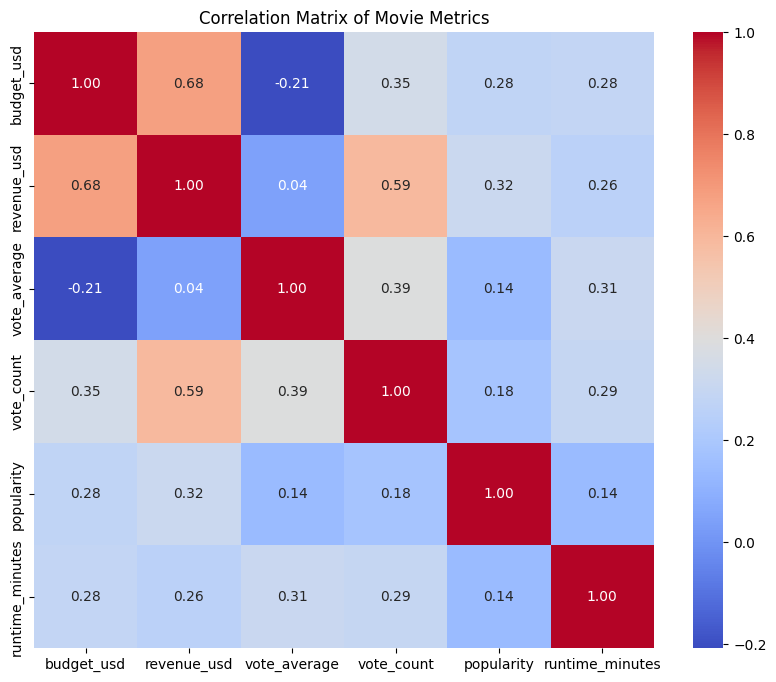


Correlation between budget_usd and vote_average: -0.207


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numerical columns
numerical_cols = ['budget_usd', 'revenue_usd', 'vote_average', 'vote_count', 'popularity', 'runtime_minutes']
corr_matrix = df[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Movie Metrics')
plt.show()

# Print the correlation between 'budget_usd' and 'vote_average'
print(f"\nCorrelation between budget_usd and vote_average: {corr_matrix.loc['budget_usd', 'vote_average']:.3f}")

---
# **Feature Engineering of Success Metrics**
---

###**1. Probability Ratio**

```
Profitability = (Revenue - Budget) / Budget
```

Here it is `roi_percentage` (already calculated)


###**2. Log-Revenue & Log-Budget**

Used to fix skewness

In [ ]:
df = df.copy()
# Log transforms for skewed financial columns
df['log_revenue'] = np.log1p(df['revenue_usd'])
df['log_budget'] = np.log1p(df['budget_usd'])

###**3. Genre Efficiency Score**

Combine financial + rating performance:

```
GES = normalized(ROI) + normalized(Rating)
```

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalized ROI + Rating for genre efficiency score
scaler = MinMaxScaler()
df[['roi_norm', 'rating_norm']] = scaler.fit_transform(
    df[['roi_percentage', 'vote_average']]
)

# Genre Efficiency Score = normalized ROI + normalized rating
df['genre_efficiency_score'] = df['roi_norm'] + df['rating_norm']

df.head()

,imdb_id,original_title,vote_average,vote_count,revenue_usd,budget_usd,runtime_minutes,original_language,popularity,genres,...,director,release_year,release_month,roi_percentage,success_category,log_revenue,log_budget,roi_norm,rating_norm,genre_efficiency_score
0,tt1375666,Inception,8.364,34495,825532764,160000000,148,en,83.952,"Action, Science Fiction, Adventure",...,Christopher Nolan,2010,7,416,All-Time Blockbuster,20.531540,18.890684,0.001245,0.923301,0.924546
1,tt0816692,Interstellar,8.417,32571,701729206,165000000,169,en,140.241,"Adventure, Drama, Science Fiction",...,Christopher Nolan,2014,11,325,Blockbuster,20.369058,18.921456,0.001026,0.935152,0.936178
2,tt0468569,The Dark Knight,8.512,30619,1004558444,185000000,152,en,130.643,"Drama, Action, Crime, Thriller",...,Christopher Nolan,2008,7,443,All-Time Blockbuster,20.727814,19.035866,0.001310,0.956395,0.957706
3,tt0499549,Avatar,7.573,29815,2923706026,237000000,162,en,79.932,"Action, Adventure, Fantasy, Science Fiction",...,James Cameron,2009,12,1134,All-Time Blockbuster,21.796118,19.283571,0.002978,0.746422,0.749400
4,tt0848228,The Avengers,7.710,29166,1518815515,220000000,143,en,98.082,"Science Fiction, Action, Adventure",...,Joss Whedon Robert,2012,4,590,All-Time Blockbuster,21.141197,19.209138,0.001665,0.777057,0.778722


###**4. Director Consistency Index**

Variance of their movie ratings or ROI:
```
Consistency = 1 / variance(ratings of director)
```

In [ ]:
# Calculate variance of rating and ROI for each director
director_stats = df.groupby('director').agg({
    'vote_average': 'var',
    'roi_percentage': 'var'
}).rename(columns={
    'vote_average': 'rating_variance',
    'roi_percentage': 'roi_variance'
})

In [ ]:
# Director consistency = 1 / rating variance
director_stats['director_consistency'] = 1 / director_stats['rating_variance']

In [ ]:
# Merge back into main df
df = df.merge(director_stats[['director_consistency']],
              left_on='director', right_index=True, how='left')

# Fill missing consistency with median
df['director_consistency'].fillna(df['director_consistency'].median(), inplace=True)

df.head()

/tmp/ipython-input-2104845994.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director_consistency'].fillna(df['director_consistency'].median(), inplace=True)


,imdb_id,original_title,vote_average,vote_count,revenue_usd,budget_usd,runtime_minutes,original_language,popularity,genres,...,release_year,release_month,roi_percentage,success_category,log_revenue,log_budget,roi_norm,rating_norm,genre_efficiency_score,director_consistency
0,tt1375666,Inception,8.364,34495,825532764,160000000,148,en,83.952,"Action, Science Fiction, Adventure",...,2010,7,416,All-Time Blockbuster,20.531540,18.890684,0.001245,0.923301,0.924546,3.828848
1,tt0816692,Interstellar,8.417,32571,701729206,165000000,169,en,140.241,"Adventure, Drama, Science Fiction",...,2014,11,325,Blockbuster,20.369058,18.921456,0.001026,0.935152,0.936178,3.828848
2,tt0468569,The Dark Knight,8.512,30619,1004558444,185000000,152,en,130.643,"Drama, Action, Crime, Thriller",...,2008,7,443,All-Time Blockbuster,20.727814,19.035866,0.001310,0.956395,0.957706,3.828848
3,tt0499549,Avatar,7.573,29815,2923706026,237000000,162,en,79.932,"Action, Adventure, Fantasy, Science Fiction",...,2009,12,1134,All-Time Blockbuster,21.796118,19.283571,0.002978,0.746422,0.749400,8.671029
4,tt0848228,The Avengers,7.710,29166,1518815515,220000000,143,en,98.082,"Science Fiction, Action, Adventure",...,2012,4,590,All-Time Blockbuster,21.141197,19.209138,0.001665,0.777057,0.778722,10.618191


---

# Statistical Reliability of Ratings (Bootstrap + Confidence Intervals)

---

We only use `vote_average` for reliability analysis.

### **1. Bootstrap CI Function**

In [ ]:
def bootstrap_ci(data, sample_size, num_bootstrap=1000, ci=0.95):
    """
    Bootstrap confidence interval for sample mean.
    """
    means = []

    for i in range(num_bootstrap):
        sample = np.random.choice(data, size=sample_size, replace=True)
        means.append(np.mean(sample))

    lower = np.percentile(means, ((1-ci)/2)*100)
    upper = np.percentile(means, (1 - (1-ci)/2)*100)

    return lower, upper, means

### **2. CI Width vs Sample Size Plot**

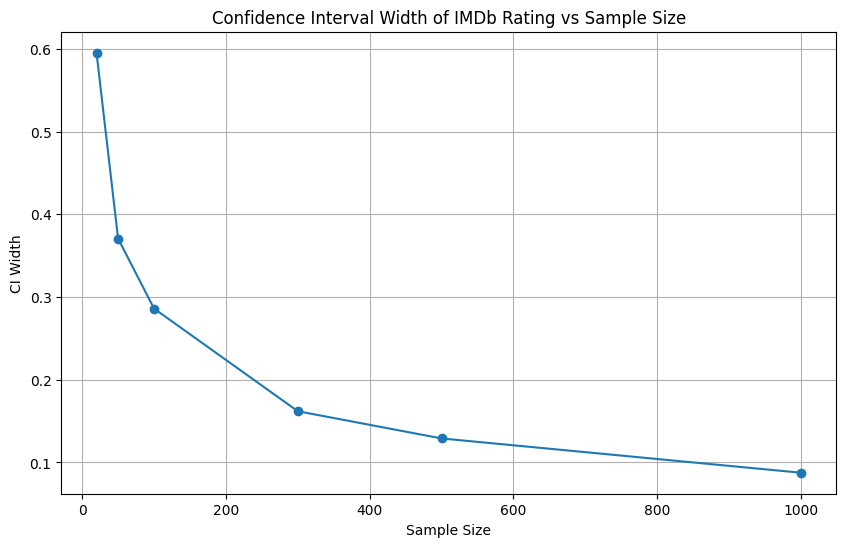

In [ ]:
rating_data = df['vote_average'].dropna().values

sample_sizes = [20, 50, 100, 300, 500, 1000]
ci_widths = []

for size in sample_sizes:
    lower, upper, _ = bootstrap_ci(rating_data, sample_size=size, num_bootstrap=600)
    ci_widths.append(upper - lower)

plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, ci_widths, marker='o')
plt.title("Confidence Interval Width of IMDb Rating vs Sample Size")
plt.xlabel("Sample Size")
plt.ylabel("CI Width")
plt.grid(True)
plt.show()

### **3. Bootstrap Sampling Distribution Plot**

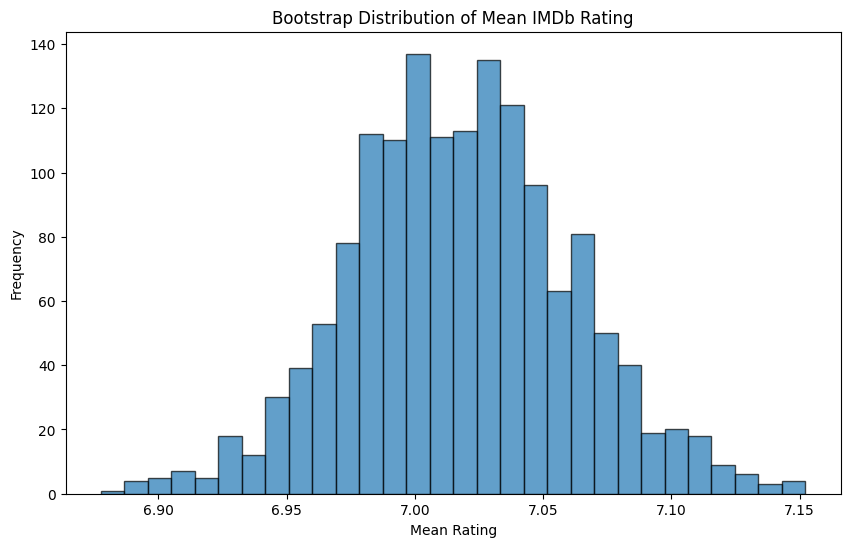

In [ ]:
bootstrap_means = []

for _ in range(1500):
    sample = np.random.choice(rating_data, size=300, replace=True)
    bootstrap_means.append(np.mean(sample))

plt.figure(figsize=(10,6))
plt.hist(bootstrap_means, bins=30, alpha=0.7, edgecolor='black')
plt.title("Bootstrap Distribution of Mean IMDb Rating")
plt.xlabel("Mean Rating")
plt.ylabel("Frequency")
plt.show()